# 🏘️ Boston Housing Data Analysis

## Overview
This notebook contains a statistical analysis of the **Boston Housing** dataset, completed as part of the AI Bootcamp. The analysis combines statistical concepts with data visualization using **Matplotlib** to better understand the relationships between housing features and property values.

## Objective
The goal of this exercise is to perform exploratory data analysis (EDA), compute descriptive statistics, and visualize important patterns in the dataset.

## Skills Practiced
- Exploratory Data Analysis (EDA)
- Descriptive Statistics
- Data Visualization with Matplotlib
- Distribution Analysis
- Correlation Analysis
- Interpreting Statistical Results

---
**Tools:** Python, NumPy, Pandas, Matplotlib

In [1]:
#import libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("BostonHousing.csv")

In [4]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


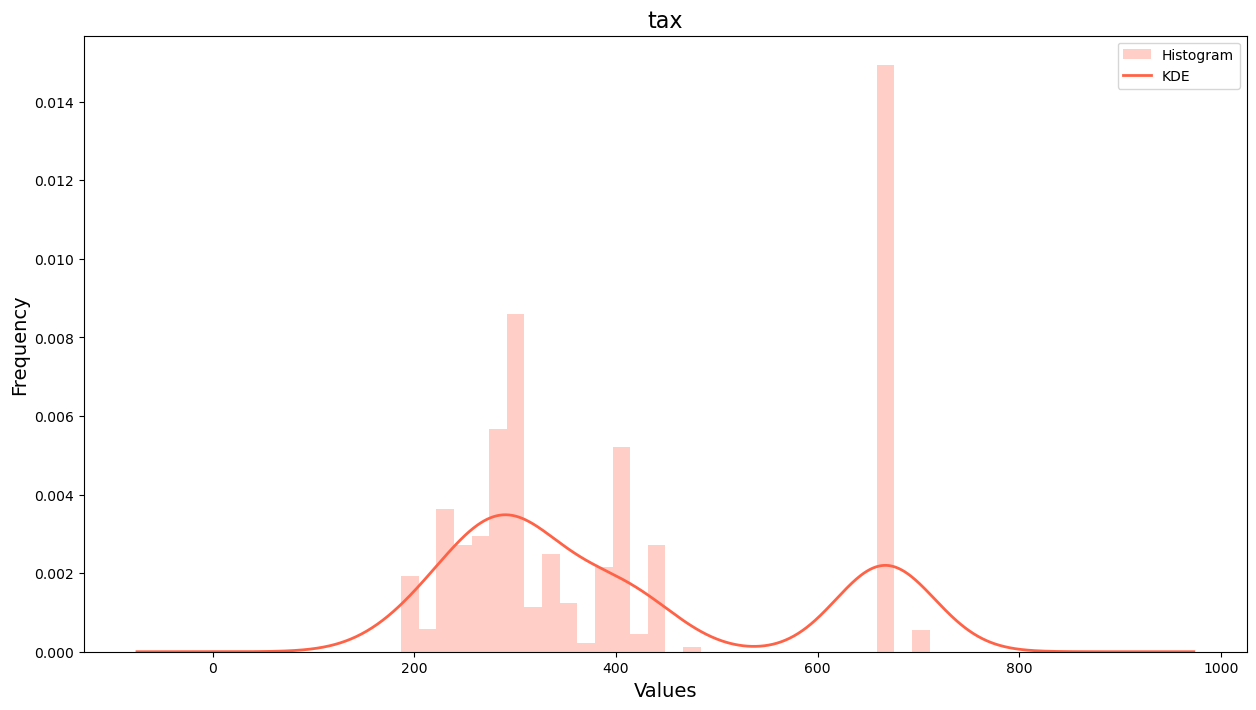

In [5]:
plt.figure(figsize=(15, 8))
plt.hist(df["tax"], bins=30, color="tomato", alpha=0.3, density=True, label="Histogram")
df["tax"].plot(kind="kde", color="tomato", linewidth=2, label="KDE")
plt.title("tax", fontsize=16)
plt.xlabel("Values", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.legend()
plt.show()

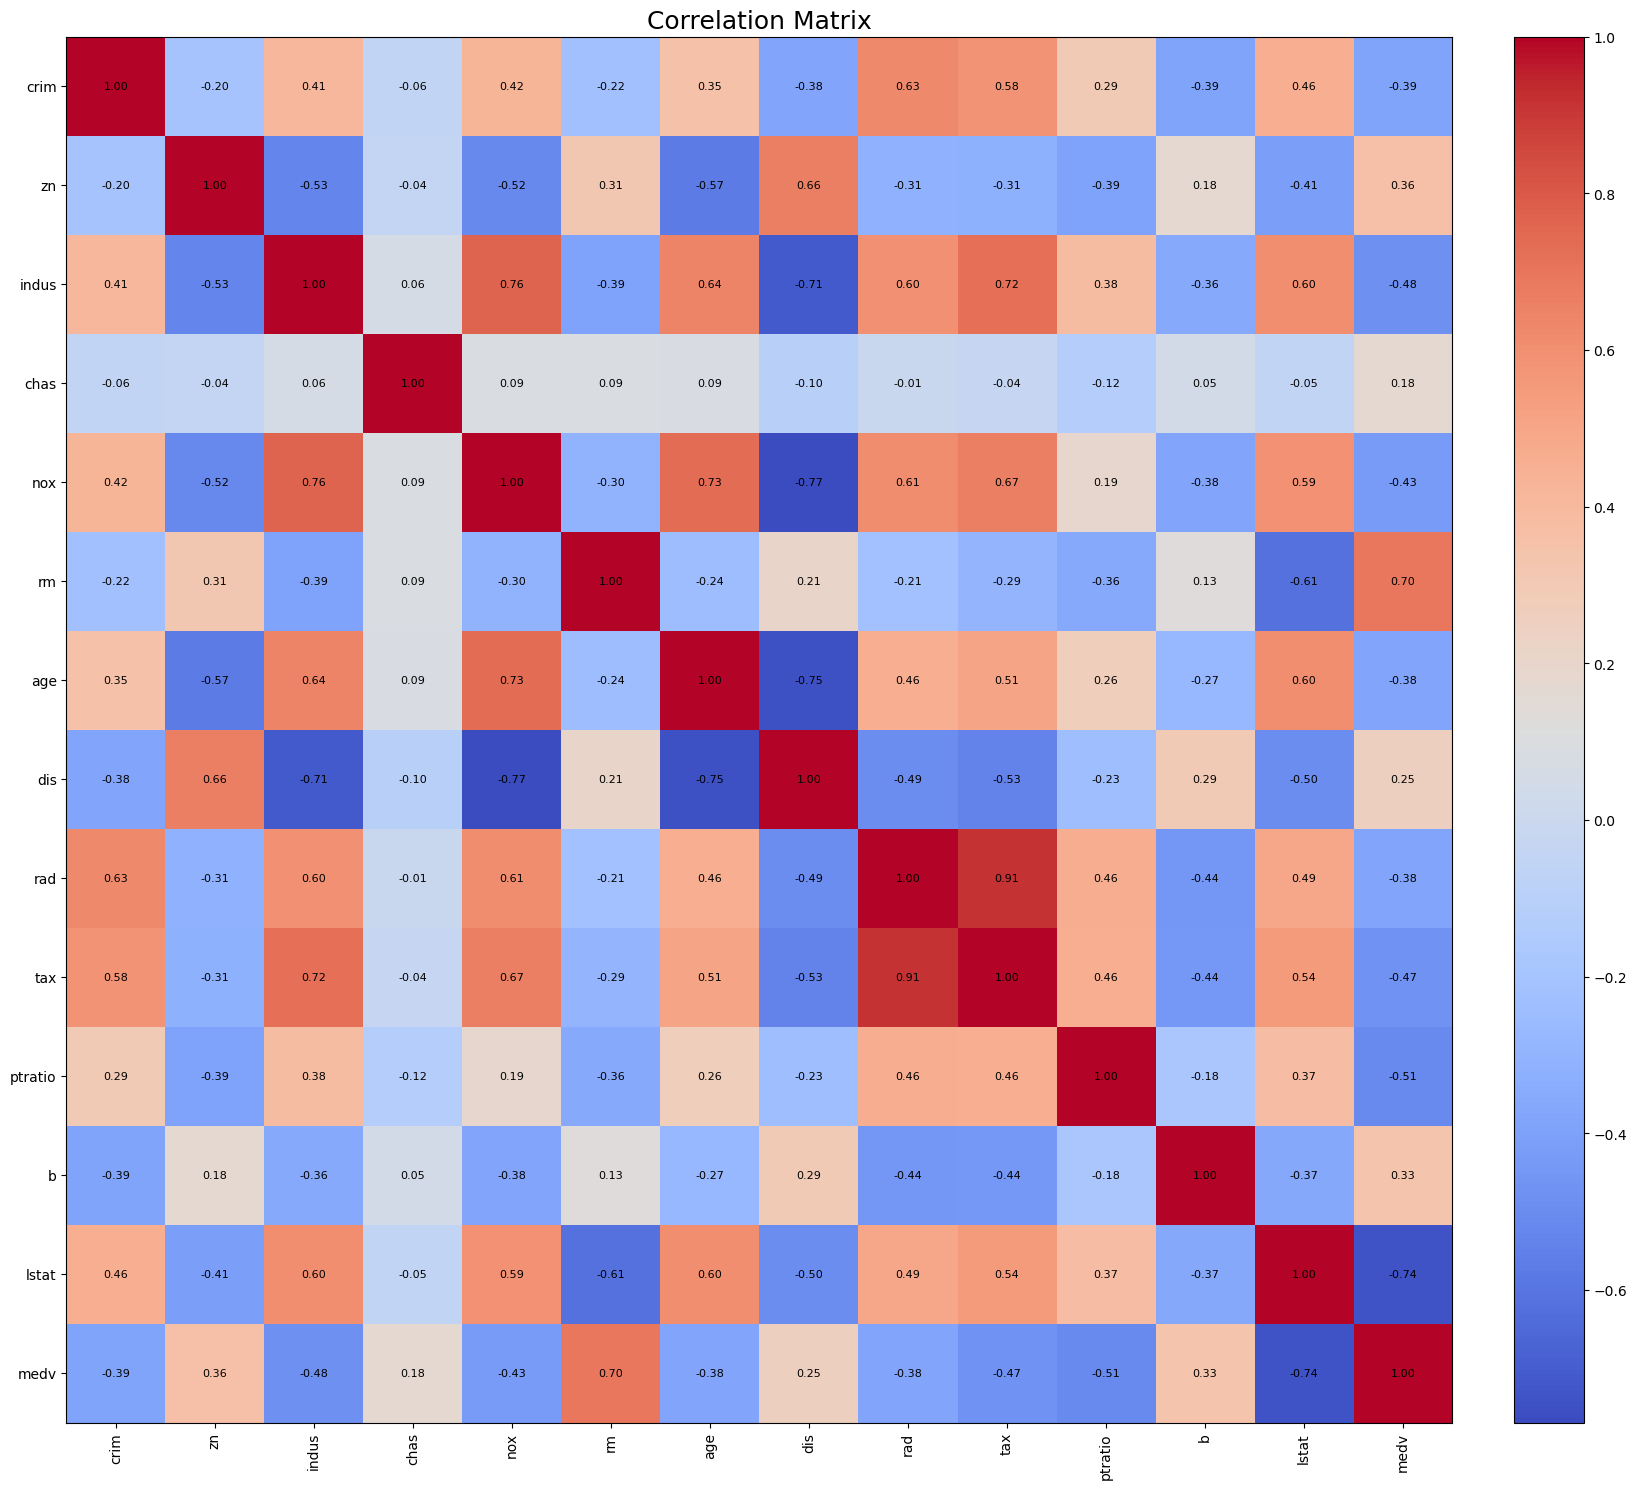

In [6]:
corr_matrix = df.corr()

plt.figure(figsize=(20, 18))
plt.title("Correlation Matrix", fontsize=18)

im = plt.imshow(corr_matrix, cmap="coolwarm")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(ticks=np.arange(len(corr_matrix.columns)), labels=corr_matrix.columns, rotation=90)
plt.yticks(ticks=np.arange(len(corr_matrix.columns)), labels=corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black", fontsize=8)

plt.show()

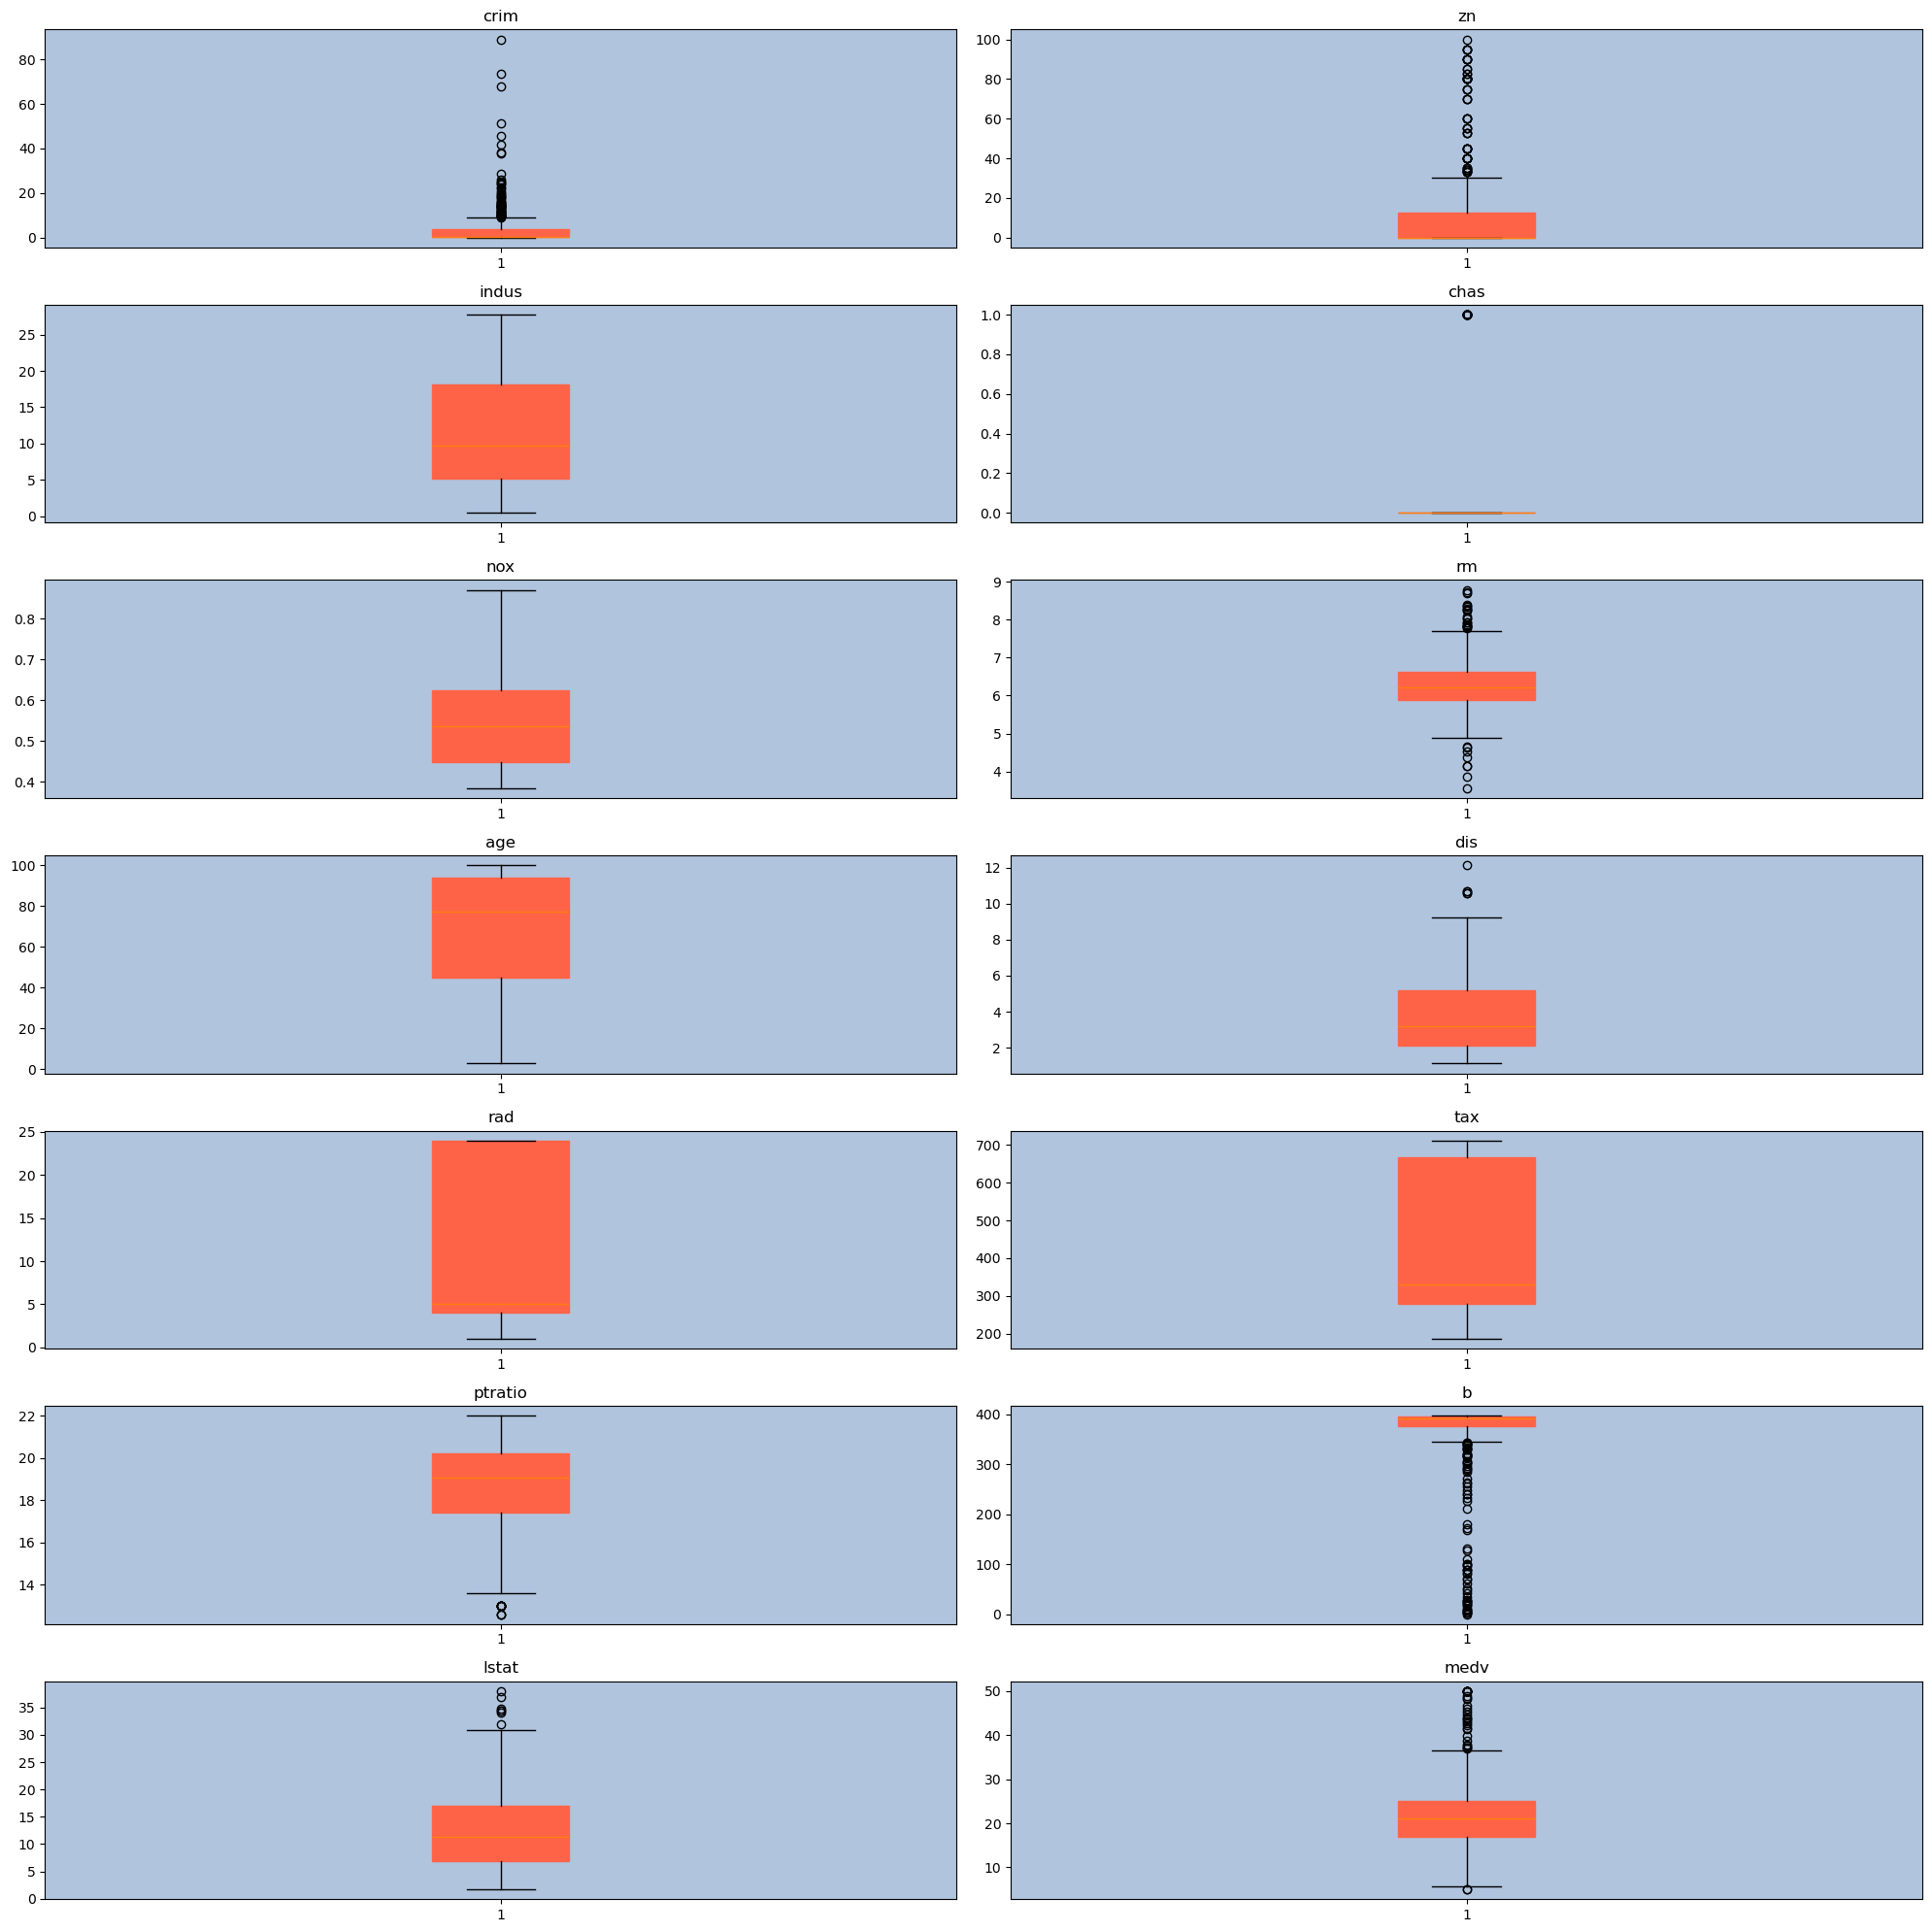

In [7]:
fig, axes = plt.subplots(7, 2, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor="tomato", color="tomato"))
    axes[i].set_facecolor("lightsteelblue")
    axes[i].set_title(col, fontsize=12)

plt.tight_layout()
plt.show()

In [8]:
df_rep = df.copy()

In [9]:
for col in df_rep.columns:
    if set(df_rep[col].unique()) == {0, 1}:
        continue
    Q1 = df_rep[col].quantile(0.25)
    Q3 = df_rep[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_rep[col] = np.where(df_rep[col] < lower_bound, lower_bound, df_rep[col])
    df_rep[col] = np.where(df_rep[col] > upper_bound, upper_bound, df_rep[col])

In [10]:
df_rep.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,2.225032,6.963439,11.136779,0.069170,0.554695,6.275312,68.574901,3.783947,9.549407,408.237154,18.463834,381.918836,12.612011,21.877075
std,3.313353,12.028788,6.860353,0.253994,0.115878,0.630242,28.148861,2.069765,8.707259,168.537116,2.143924,19.054913,7.016829,7.602976
min,0.006320,0.000000,0.460000,0.000000,0.385000,4.778500,2.900000,1.129600,1.000000,187.000000,13.200000,344.106250,1.730000,5.062500
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,9.069639,31.250000,27.740000,1.000000,0.871000,7.730500,100.000000,9.820800,24.000000,711.000000,22.000000,396.900000,31.962500,36.962500


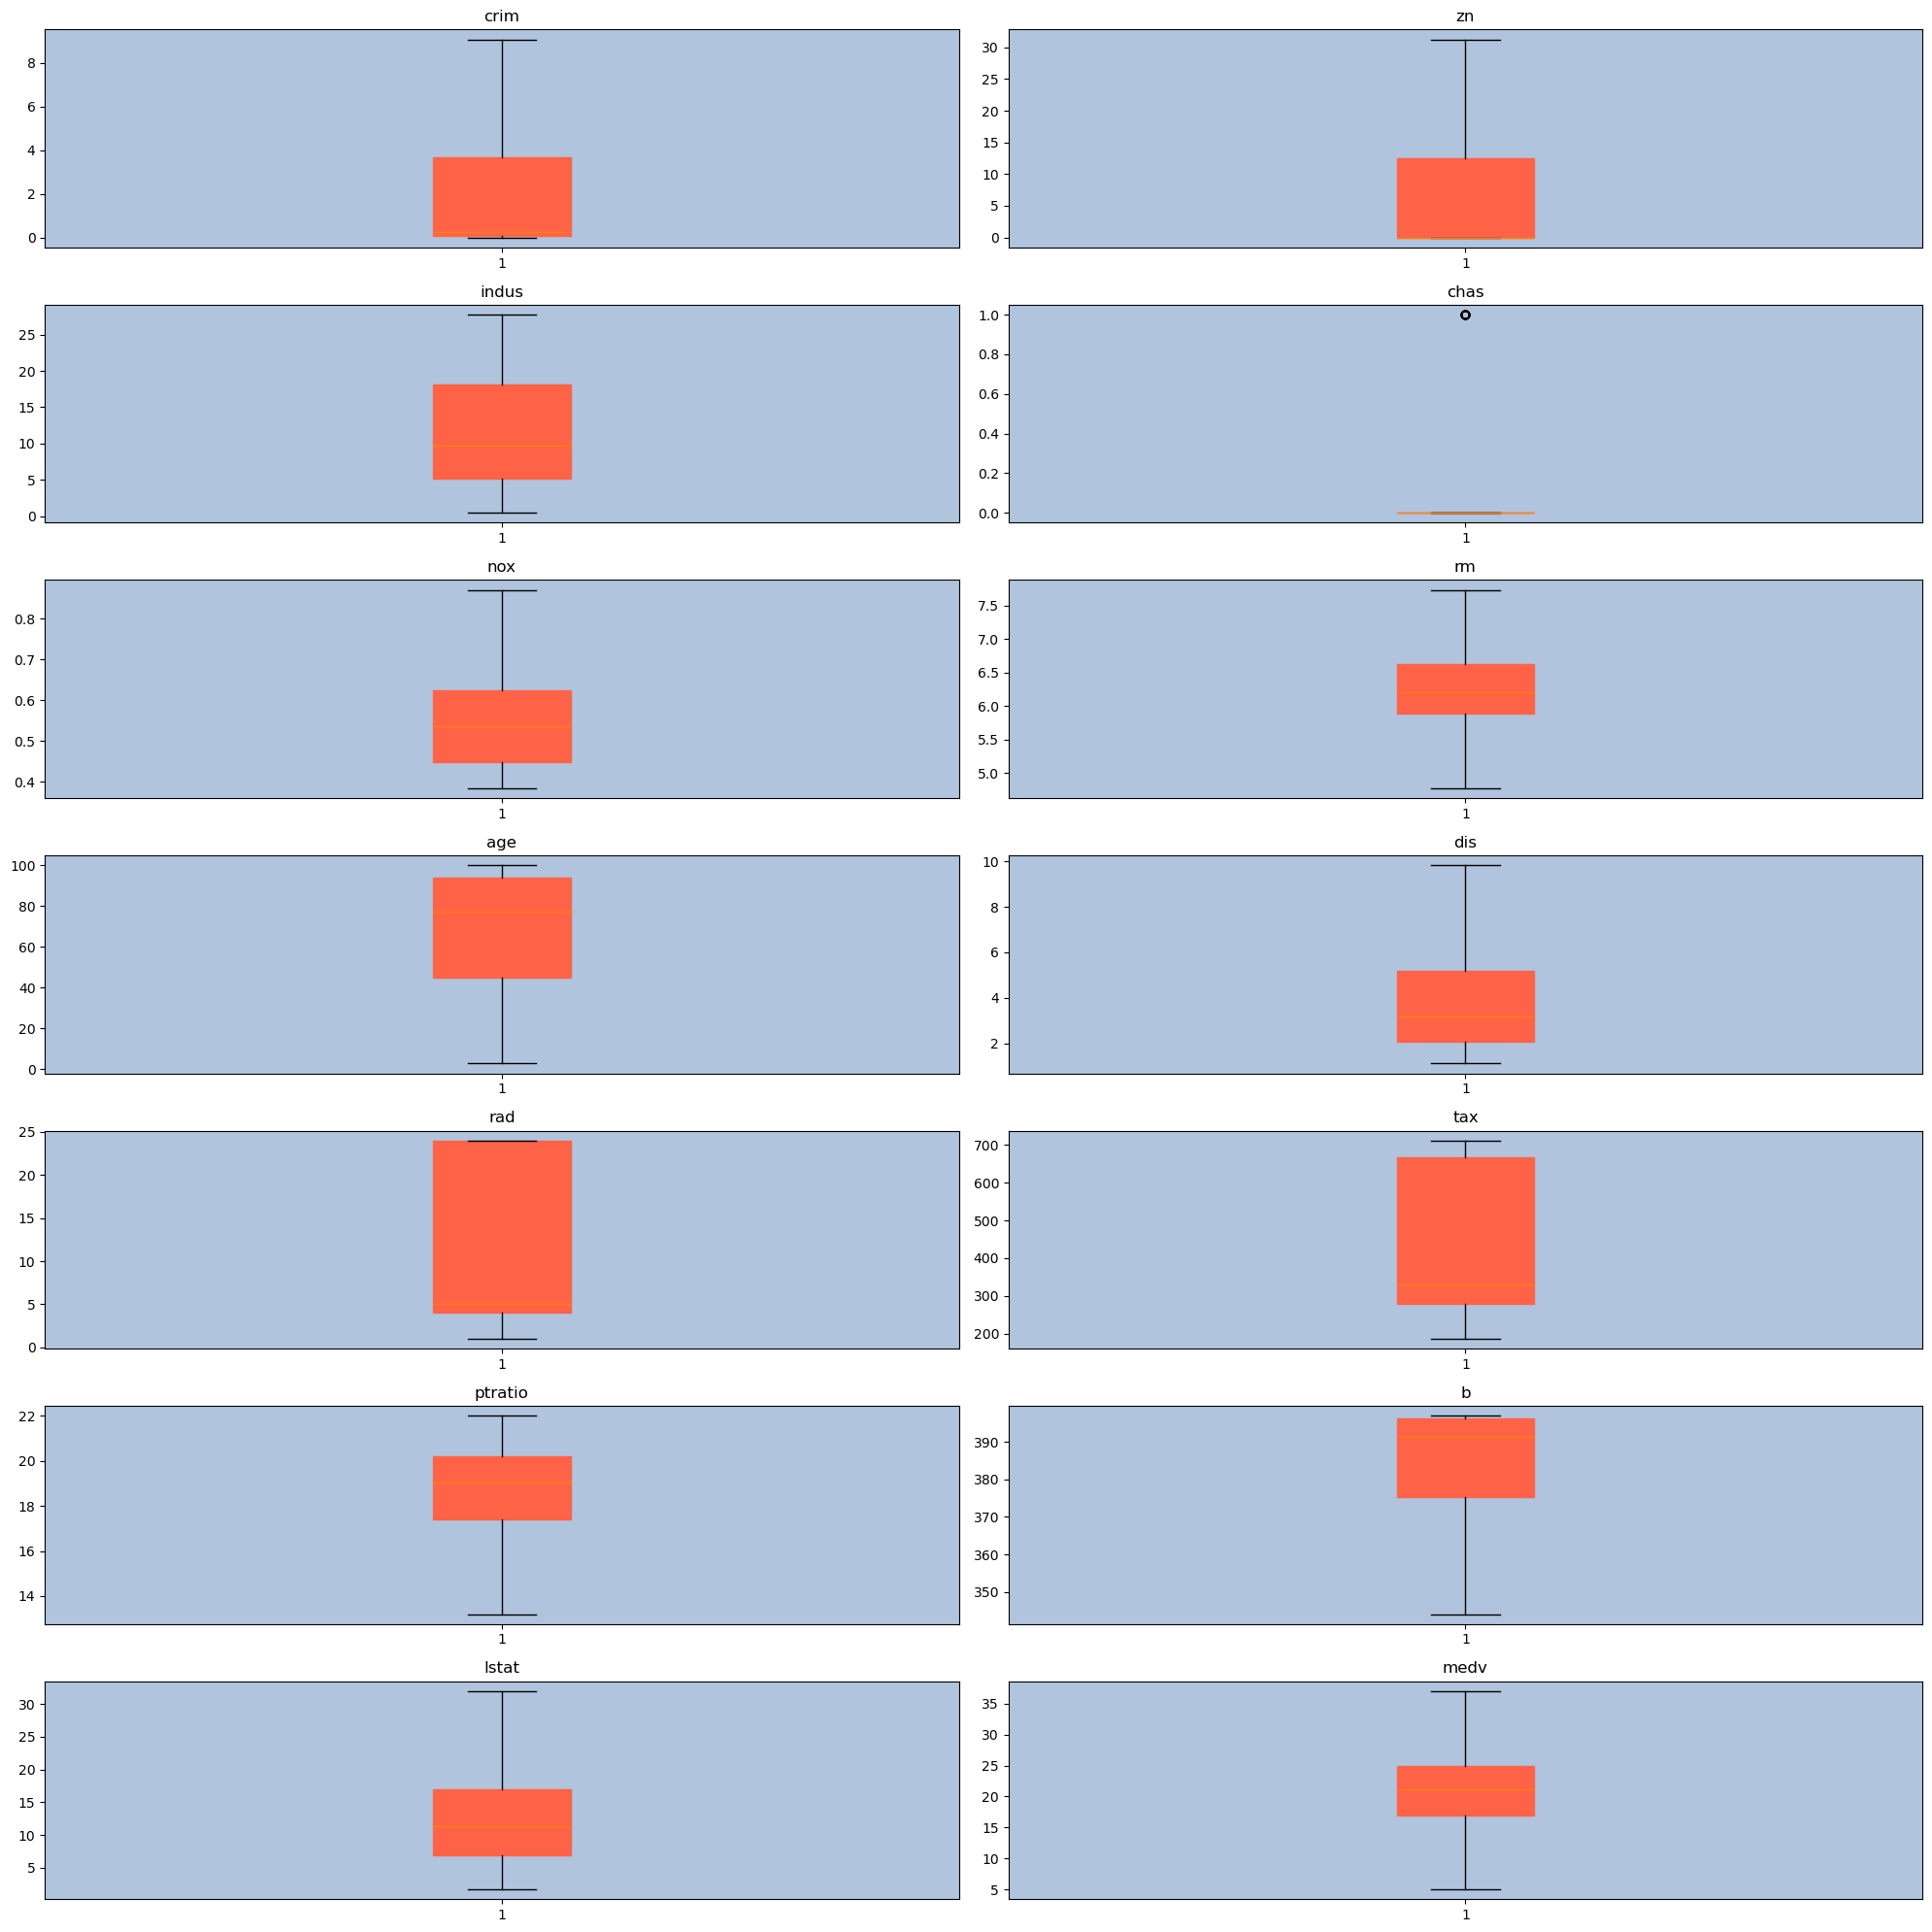

In [11]:
fig, axes = plt.subplots(7, 2, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(df_rep.columns):
    axes[i].boxplot(df_rep[col], patch_artist=True,
                    boxprops=dict(facecolor="tomato", color="tomato"))
    axes[i].set_facecolor("lightsteelblue")
    axes[i].set_title(col, fontsize=12)

plt.tight_layout()
plt.show()

In [12]:
df_zscore = df.copy()
z_scores = (df_zscore["dis"] - df_zscore["dis"].mean()) / df_zscore["dis"].std()
df_zscore = df_zscore[np.abs(z_scores) <= 3]

df_iqr = df.copy()
Q1 = df_iqr["dis"].quantile(0.25)
Q3 = df_iqr["dis"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_iqr = df_iqr[(df_iqr["dis"] >= lower_bound) & (df_iqr["dis"] <= upper_bound)]

In [13]:
var_zscore = df_zscore["dis"].var()
var_iqr = df_iqr["dis"].var()
print("Variance after Z-Score method:", var_zscore)
print("Variance after IQR method:", var_iqr)

Variance after Z-Score method: 3.958693555278562
Variance after IQR method: 3.958693555278562


In [14]:
var_difference = abs(var_zscore - var_iqr)

In [15]:
from scipy.stats import shapiro

for col in df_zscore.columns:
    stat, p = shapiro(df_zscore[col])
    print(f"Shapiro-Wilk test for {col}: statistic={stat:.4f}, p-value={p:.4f}")

Shapiro-Wilk test for crim: statistic=0.4522, p-value=0.0000
Shapiro-Wilk test for zn: statistic=0.5456, p-value=0.0000
Shapiro-Wilk test for indus: statistic=0.9002, p-value=0.0000
Shapiro-Wilk test for chas: statistic=0.2764, p-value=0.0000
Shapiro-Wilk test for nox: statistic=0.9370, p-value=0.0000
Shapiro-Wilk test for rm: statistic=0.9610, p-value=0.0000
Shapiro-Wilk test for age: statistic=0.8912, p-value=0.0000
Shapiro-Wilk test for dis: statistic=0.9093, p-value=0.0000
Shapiro-Wilk test for rad: statistic=0.6816, p-value=0.0000
Shapiro-Wilk test for tax: statistic=0.8137, p-value=0.0000
Shapiro-Wilk test for ptratio: statistic=0.8975, p-value=0.0000
Shapiro-Wilk test for b: statistic=0.4783, p-value=0.0000
Shapiro-Wilk test for lstat: statistic=0.9386, p-value=0.0000
Shapiro-Wilk test for medv: statistic=0.9172, p-value=0.0000


In [16]:
from scipy.stats import ttest_ind

median_age = df_zscore["age"].median()

older_houses = df_zscore[df_zscore["age"] >= median_age]["dis"]
newer_houses = df_zscore[df_zscore["age"] < median_age]["dis"]

stat, p = ttest_ind(older_houses, newer_houses, equal_var=False)
print(f"T-test statistic={stat:.4f}, p-value={p:.4f}")

T-test statistic=-19.6365, p-value=0.0000


In [19]:
median_ptratio = df_zscore["ptratio"].median()

high_school_area = df_zscore[df_zscore["ptratio"] >= median_ptratio]["nox"]
low_school_area = df_zscore[df_zscore["ptratio"] < median_ptratio]["nox"]

stat, p = ttest_ind(high_school_area, low_school_area, equal_var=False)
print(f"T-test statistic={stat:.4f}, p-value={p:.4f}")

T-test statistic=10.1697, p-value=0.0000


In [20]:
mean_lstat = df_zscore["lstat"].mean()

high_density = df_zscore[df_zscore["lstat"] >= mean_lstat]["rm"]
low_density = df_zscore[df_zscore["lstat"] < mean_lstat]["rm"]

stat, p = ttest_ind(high_density, low_density, equal_var=False)
print(f"T-test statistic={stat:.4f}, p-value={p:.4f}")

T-test statistic=-12.1724, p-value=0.0000
